In [1]:
# ============================================================
# 0. 导入需要用到的 Python 库
# ============================================================
# os / glob：用于处理文件路径、自动查找文件
import os
import glob
import warnings
import json
# numpy：数值计算，后面 CNN 输入矩阵 X 会用 numpy 数组保存
import numpy as np
# pandas：读取和处理表格时间序列数据，比如 GESLA 潮位数据
import pandas as pd
# matplotlib：画图检查数据是否正常
import matplotlib.pyplot as plt
# xarray：读取 ERA20C 的 grib 气象数据
import xarray as xr
# sklearn：标准化、数据划分
from sklearn.preprocessing import StandardScaler
# UTide：做潮汐调和分析，用于潮汐分离
from utide import solve, reconstruct
# matplotlib.dates：把 datetime 时间转成 UTide 可用的数值时间
import matplotlib.dates as mdates
# 忽略一些不影响运行的警告
warnings.filterwarnings("ignore")

In [2]:
# ============================================================
# 1. 设置路径和站点基本信息
# ============================================================

# 当前测试年份
# 现在只复制了 1985 年 ERA20C，所以这里先写 1985
YEAR = 1985

# 数据总目录
BASE_DIR = r"E:\AAAqian\code\storm_surge\data"

# ERA20C 数据目录
ERA_DIR = os.path.join(BASE_DIR, "ERA20C_1985")

# 厦门 GESLA 潮位文件路径
GESLA_FILE = os.path.join(
    BASE_DIR,
    "xiamen_GESLA",
    "xiamen-376a-chn-uhslc"
)

# 预处理结果输出目录
OUT_DIR = os.path.join(BASE_DIR, "processed_xiamen_1985")
os.makedirs(OUT_DIR, exist_ok=True)

# 厦门站基本信息
# 这些信息来自 GESLA 文件头部
SITE_NAME = "Xiamen"
SITE_LAT = 24.45
SITE_LON = 118.067

# 自动查找 1985 年的三个 ERA20C 文件
U10_FILE = glob.glob(os.path.join(ERA_DIR, "10U", f"*{YEAR}*.grb"))[0]
V10_FILE = glob.glob(os.path.join(ERA_DIR, "10V", f"*{YEAR}*.grb"))[0]
SLP_FILE = glob.glob(os.path.join(ERA_DIR, "SLP", f"*{YEAR}*.grb"))[0]

print("U10 文件:", U10_FILE)
print("V10 文件:", V10_FILE)
print("SLP 文件:", SLP_FILE)
print("GESLA 文件:", GESLA_FILE)

U10 文件: E:\AAAqian\code\storm_surge\data\ERA20C_1985\10U\e20c.oper.an.sfc.3hr.128_165_10u.regn80sc.1985010100_1985123121.grb
V10 文件: E:\AAAqian\code\storm_surge\data\ERA20C_1985\10V\e20c.oper.an.sfc.3hr.128_166_10v.regn80sc.1985010100_1985123121.grb
SLP 文件: E:\AAAqian\code\storm_surge\data\ERA20C_1985\SLP\e20c.oper.an.sfc.3hr.128_151_msl.regn80sc.1985010100_1985123121.grb
GESLA 文件: E:\AAAqian\code\storm_surge\data\xiamen_GESLA\xiamen-376a-chn-uhslc


In [3]:
# ============================================================
# 2. 找到 GESLA 文件中真正数据开始的行
# ============================================================

def find_data_start_line(file_path):
    """
    GESLA 文件前面有很多以 # 开头的说明信息，
    比如站点名、经纬度、时间范围等。

    真正的潮位数据从第一个“不以 # 开头”的行开始。
    这个函数就是自动找到数据开始的行号。
    """

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if not line.startswith("#"):
                return i

    raise ValueError("没有找到数据开始行，请检查 GESLA 文件格式。")


start_line = find_data_start_line(GESLA_FILE)
print("GESLA 数据开始行:", start_line)

GESLA 数据开始行: 41


In [4]:
# ============================================================
# 3. 读取 GESLA 原始潮位数据
# ============================================================

raw = pd.read_csv(
    GESLA_FILE,
    skiprows=start_line,       # 跳过文件头部注释
    sep=r"\s+",              # GESLA 数据一般用空格分隔
    header=None                # 原始文件没有表头
)

print("原始数据前5行:")
display(raw.head())

print("原始数据形状:", raw.shape)

原始数据前5行:


,0,1,2,3,4
0,1954/01/01,00:00:00,4.50,1,1
1,1954/01/01,01:00:00,4.92,1,1
2,1954/01/01,02:00:00,5.08,1,1
3,1954/01/01,03:00:00,4.80,1,1
4,1954/01/01,04:00:00,4.14,1,1


原始数据形状: (385696, 5)


In [5]:
# ============================================================
# 4. 给 GESLA 数据添加列名，并整理时间
# ============================================================

# 常见 GESLA 数据列一般是：
# 第1列：日期
# 第2列：时间
# 第3列：水位 sea_level
# 第4列：质量控制标记 qc_flag
# 第5列：使用标记 use_flag

print("GESLA 原始列数:", raw.shape[1])

if raw.shape[1] >= 5:
    raw = raw.iloc[:, :5]
    raw.columns = ["date", "time", "sea_level", "qc_flag", "use_flag"]

elif raw.shape[1] == 4:
    raw.columns = ["date", "time", "sea_level", "qc_flag"]
    raw["use_flag"] = 1

else:
    raise ValueError("GESLA 列数不符合预期，请先查看 raw.head()。")


# 合并 date 和 time，生成 datetime 时间列
raw["datetime"] = pd.to_datetime(
    raw["date"].astype(str) + " " + raw["time"].astype(str),
    errors="coerce"
)

# 将水位列转成数字
raw["sea_level"] = pd.to_numeric(raw["sea_level"], errors="coerce")

# 只保留后面需要的列
df = raw[["datetime", "sea_level", "qc_flag", "use_flag"]].copy()

# 删除时间或水位为空的数据
df = df.dropna(subset=["datetime", "sea_level"])

# 按时间排序
df = df.sort_values("datetime")

# 删除重复时间
df = df.drop_duplicates(subset=["datetime"])

display(df.head())
display(df.tail())

print("整理后数据形状:", df.shape)

GESLA 原始列数: 5


,datetime,sea_level,qc_flag,use_flag
0,1954-01-01 00:00:00,4.50,1,1
1,1954-01-01 01:00:00,4.92,1,1
2,1954-01-01 02:00:00,5.08,1,1
3,1954-01-01 03:00:00,4.80,1,1
4,1954-01-01 04:00:00,4.14,1,1


,datetime,sea_level,qc_flag,use_flag
385691,1997-12-31 11:00:00,2.05,1,1
385692,1997-12-31 12:00:00,1.94,1,1
385693,1997-12-31 13:00:00,2.62,1,1
385694,1997-12-31 14:00:00,3.63,1,1
385695,1997-12-31 15:00:00,4.52,1,1


整理后数据形状: (385696, 4)


In [6]:
# ============================================================
# 5. 筛选 1985 年数据，并处理明显缺测值
# ============================================================

# 只保留 1985 年
df = df[df["datetime"].dt.year == YEAR].copy()

# GESLA 或潮位数据里常见的缺测值标记
# 不同数据集可能会用 -99, -999, -9999, 9999 等表示缺测
bad_values = [-99, -999, -9999, 9999, 99999]

# 将这些异常缺测值替换成 NaN
df.loc[df["sea_level"].isin(bad_values), "sea_level"] = np.nan

# 如果 use_flag 为 0，通常表示不推荐使用
# 这里做一个宽松处理：只删除 use_flag == 0 的数据
df = df[df["use_flag"] != 0].copy()

# 删除缺测水位
df = df.dropna(subset=["sea_level"])

print("1985 年清洗前基本统计:")
display(df["sea_level"].describe())

print("1985 年数据量:", df.shape)
display(df.head())

1985 年清洗前基本统计:


count    8760.000000
mean        3.581476
std         1.436391
min         0.360000
25%         2.400000
50%         3.510000
75%         4.830000
max         6.810000
Name: sea_level, dtype: float64

1985 年数据量: (8760, 4)


,datetime,sea_level,qc_flag,use_flag
271752,1985-01-01 00:00:00,4.56,1,1
271753,1985-01-01 01:00:00,4.19,1,1
271754,1985-01-01 02:00:00,3.60,1,1
271755,1985-01-01 03:00:00,3.02,1,1
271756,1985-01-01 04:00:00,2.60,1,1


In [7]:
# ============================================================
# 6. 对原始潮位进行异常值处理
# ============================================================

def clean_sea_level_outliers(data, col="sea_level"):
    """
    对潮位数据进行异常值处理。

    这里用了两层清洗：

    1. 物理阈值：
       先删除特别离谱的数值，比如大于 10000 或小于 -10000。
       这里阈值设得比较宽松，是为了避免误删真实风暴潮。

    2. IQR 方法：
       IQR = Q3 - Q1
       正常情况下，超过 Q1 - 5*IQR 或 Q3 + 5*IQR 的点视为异常。
       这里使用 5*IQR，而不是常见的 1.5*IQR，
       是因为潮位和风暴潮本来就可能有极端值，不能删得太严格。

    异常值不直接删除，而是先设为 NaN，再用时间插值补齐。
    """

    data = data.copy()

    # 第一步：物理阈值粗筛
    data = data[(data[col] > -10000) & (data[col] < 10000)].copy()

    # 第二步：IQR 异常值判断
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 5 * iqr
    upper = q3 + 5 * iqr

    data["is_outlier"] = (data[col] < lower) | (data[col] > upper)

    print("潮位 Q1:", q1)
    print("潮位 Q3:", q3)
    print("潮位 IQR:", iqr)
    print("潮位异常值下限:", lower)
    print("潮位异常值上限:", upper)
    print("潮位异常值数量:", data["is_outlier"].sum())

    # 将异常值设为 NaN
    data.loc[data["is_outlier"], col] = np.nan

    # 按时间设索引，方便时间插值
    data = data.set_index("datetime").sort_index()

    # 时间插值
    # limit=6 表示最多连续补 6 个缺测点
    # 如果有大段缺测，不强行补
    data[col] = data[col].interpolate(
        method="time",
        limit=6,
        limit_direction="both"
    )

    # 删除仍然无法补齐的缺测值
    data = data.dropna(subset=[col])

    # 恢复 datetime 为普通列
    data = data.reset_index()

    return data


df_clean = clean_sea_level_outliers(df)

print("清洗后数据量:", df_clean.shape)
display(df_clean.head())

潮位 Q1: 2.4
潮位 Q3: 4.83
潮位 IQR: 2.43
潮位异常值下限: -9.75
潮位异常值上限: 16.98
潮位异常值数量: 0
清洗后数据量: (8760, 5)


,datetime,sea_level,qc_flag,use_flag,is_outlier
0,1985-01-01 00:00:00,4.56,1,1,False
1,1985-01-01 01:00:00,4.19,1,1,False
2,1985-01-01 02:00:00,3.60,1,1,False
3,1985-01-01 03:00:00,3.02,1,1,False
4,1985-01-01 04:00:00,2.60,1,1,False


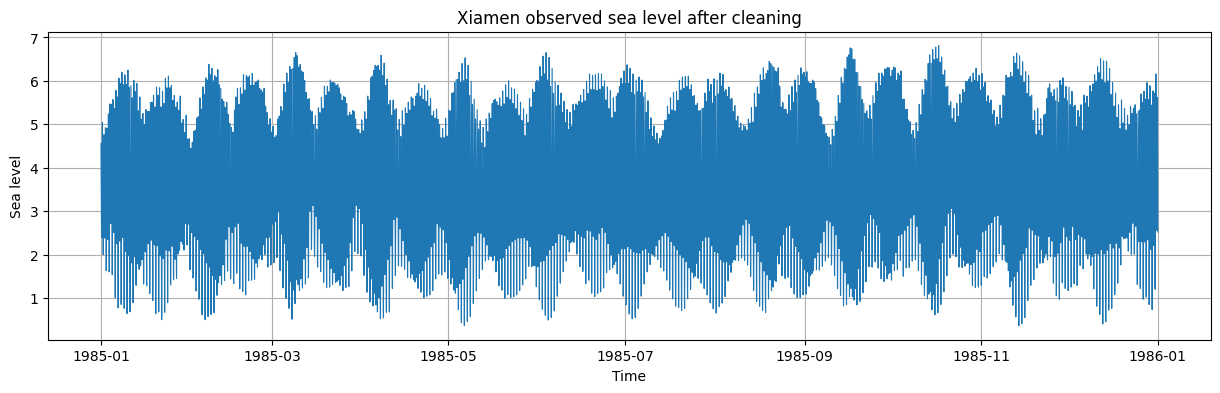

In [8]:
# ============================================================
# 7. 画图检查清洗后的原始潮位
# ============================================================

plt.figure(figsize=(15, 4))
plt.plot(df_clean["datetime"], df_clean["sea_level"], linewidth=0.8)
plt.title("Xiamen observed sea level after cleaning")
plt.xlabel("Time")
plt.ylabel("Sea level")
plt.grid(True)
plt.show()

In [9]:
# ============================================================
# 8. 使用 UTide 做潮汐调和分析
# ============================================================

# 注意：
# 这里为了跑通流程，只使用 1985 年数据做调和分析。
# 但正式复现论文时，建议使用厦门站完整观测期 1954–1997，
# 因为调和分析需要较长时间序列，结果会更稳定。

# 将 datetime 转成 UTide 可以识别的数值时间
time_num = mdates.date2num(df_clean["datetime"])

# 原始观测潮位
sea_level = df_clean["sea_level"].values

# solve：根据观测潮位估计主要分潮参数
coef = solve(
    time_num,
    sea_level,
    lat=SITE_LAT,
    method="ols",
    conf_int="linear"
)

print("潮汐调和分析完成。")

solve: matrix prep ... solution ... done.
潮汐调和分析完成。


prep/calcs ... done.


,datetime,sea_level,qc_flag,use_flag,is_outlier,tide,storm_surge
0,1985-01-01 00:00:00,4.56,1,1,False,3.499557,1.060443
1,1985-01-01 01:00:00,4.19,1,1,False,3.499557,0.690443
2,1985-01-01 02:00:00,3.60,1,1,False,3.499557,0.100443
3,1985-01-01 03:00:00,3.02,1,1,False,3.499557,-0.479557
4,1985-01-01 04:00:00,2.60,1,1,False,3.499557,-0.899557


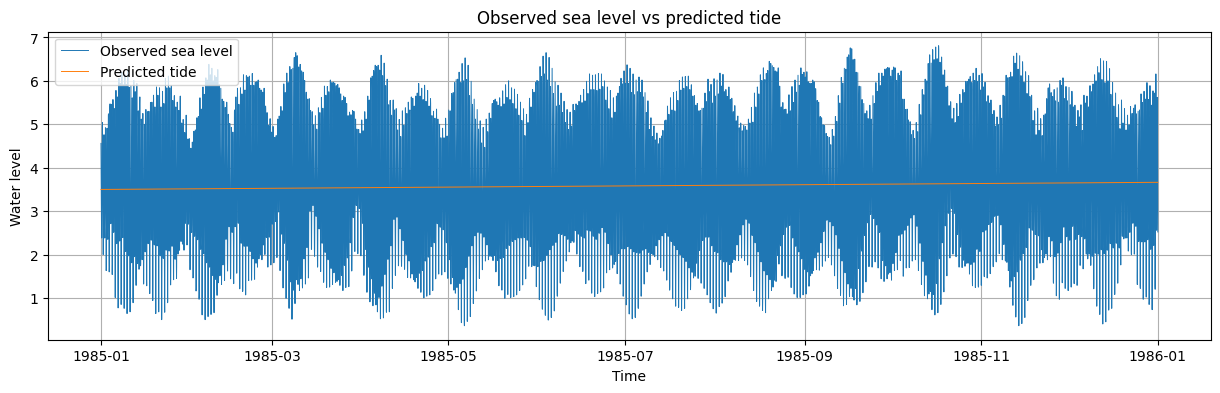

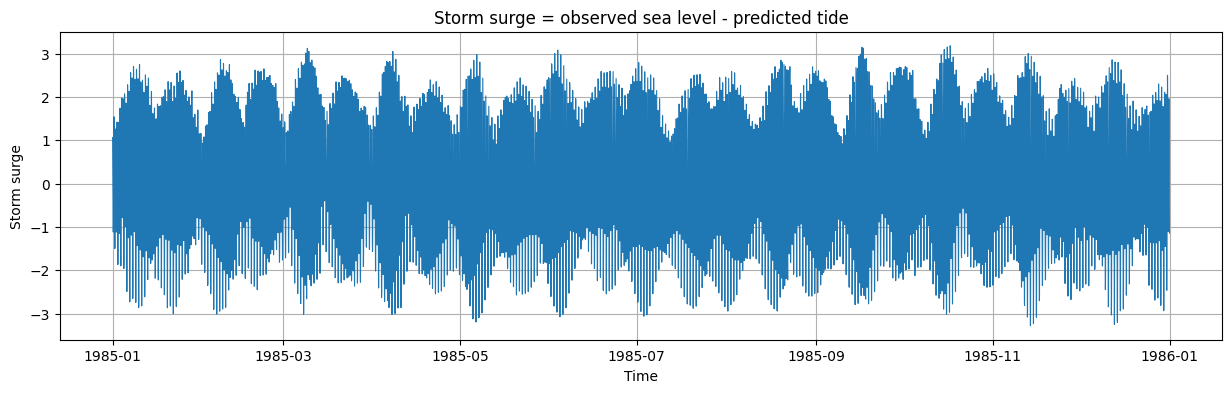

In [10]:
# ============================================================
# 9. 根据调和分析结果重建天文潮，并计算 storm surge
# ============================================================

# reconstruct：根据分潮参数重建天文潮 tide
tide = reconstruct(time_num, coef)

# 添加天文潮
df_clean["tide"] = tide.h

# 风暴潮 = 实测水位 - 天文潮
df_clean["storm_surge"] = df_clean["sea_level"] - df_clean["tide"]

display(df_clean.head())

plt.figure(figsize=(15, 4))
plt.plot(df_clean["datetime"], df_clean["sea_level"], label="Observed sea level", linewidth=0.7)
plt.plot(df_clean["datetime"], df_clean["tide"], label="Predicted tide", linewidth=0.7)
plt.title("Observed sea level vs predicted tide")
plt.xlabel("Time")
plt.ylabel("Water level")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(df_clean["datetime"], df_clean["storm_surge"], linewidth=0.8)
plt.title("Storm surge = observed sea level - predicted tide")
plt.xlabel("Time")
plt.ylabel("Storm surge")
plt.grid(True)
plt.show()

surge Q1: -1.1771372321865758
surge Q3: 1.2457150405062667
surge IQR: 2.4228522726928423
surge 异常值下限: -13.291398595650788
surge 异常值上限: 13.35997640397048
surge 异常值数量: 0


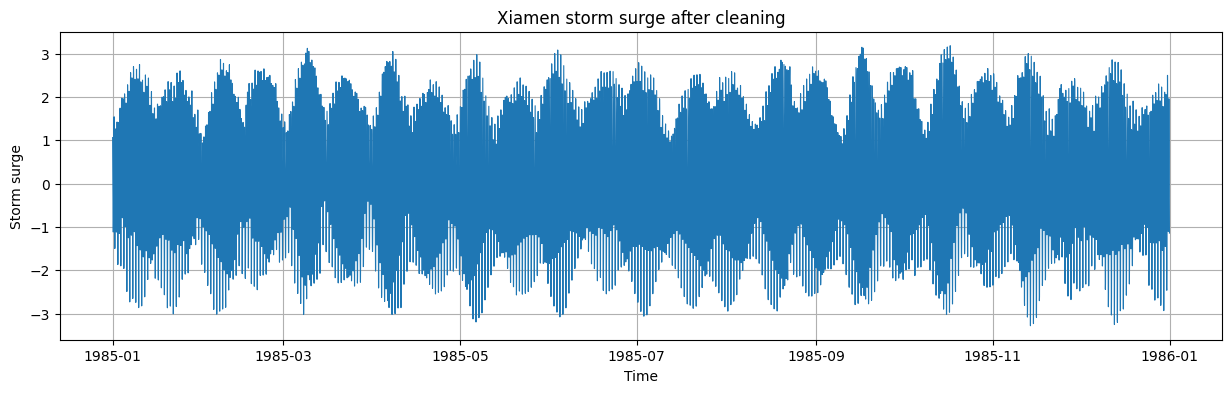

In [11]:
# ============================================================
# 10. 对 storm surge 再进行异常值处理
# ============================================================

def clean_surge_outliers(data, col="storm_surge"):
    """
    对潮汐分离后的 storm surge 做异常值检查。
    极端风暴潮本身是模型需要学习的目标，所以阈值仍用较宽松的 5*IQR。
    """
    data = data.copy()
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 5 * iqr
    upper = q3 + 5 * iqr
    data["surge_outlier"] = (data[col] < lower) | (data[col] > upper)

    print("surge Q1:", q1)
    print("surge Q3:", q3)
    print("surge IQR:", iqr)
    print("surge 异常值下限:", lower)
    print("surge 异常值上限:", upper)
    print("surge 异常值数量:", data["surge_outlier"].sum())

    data.loc[data["surge_outlier"], col] = np.nan
    data = data.set_index("datetime").sort_index()
    data[col] = data[col].interpolate(method="time", limit=6, limit_direction="both")
    data = data.dropna(subset=[col]).reset_index()
    return data


df_surge = clean_surge_outliers(df_clean)

plt.figure(figsize=(15, 4))
plt.plot(df_surge["datetime"], df_surge["storm_surge"], linewidth=0.8)
plt.title("Xiamen storm surge after cleaning")
plt.xlabel("Time")
plt.ylabel("Storm surge")
plt.grid(True)
plt.show()


In [12]:
# ============================================================
# 11. 计算逐日最大 storm surge，作为 CNN 标签 y
# ============================================================

# 论文中的 predictand 是 daily maximum storm surge，
# 所以这里按天重采样，并取每天最大 storm surge。

daily_surge = (
    df_surge
    .set_index("datetime")["storm_surge"]
    .resample("D")
    .max()
    .dropna()
)

daily_surge = daily_surge.to_frame(name="daily_max_surge")

print("逐日最大 storm surge:")
display(daily_surge.head())
print("daily_surge 数据量:", daily_surge.shape)


逐日最大 storm surge:


,daily_max_surge
datetime,
1985-01-01,1.540443
1985-01-02,1.419990
1985-01-03,1.739542
1985-01-04,1.969094
1985-01-05,2.068641


daily_surge 数据量: (365, 1)


In [13]:
# ============================================================
# 12. 读取 ERA20C 的三个 GRIB 文件
# ============================================================

def open_grib(file_path):
    """
    使用 xarray + cfgrib 打开 ERA20C 的 GRIB 文件。
    如果这里报错，通常是 cfgrib/eccodes 没装好。
    """
    try:
        ds = xr.open_dataset(file_path, engine="cfgrib", backend_kwargs={"indexpath": ""})
    except ValueError as exc:
        raise RuntimeError(
            "读取 GRIB 失败：当前环境可能缺少 cfgrib/eccodes。"
            "请先安装 cfgrib 和 eccodes 后重新运行本 Cell。"
        ) from exc
    return ds


def print_dataset_summary(name, ds):
    """
    安全打印 Dataset 摘要。
    当前环境直接 display(ds) 可能因为 dask 版本字符串异常而报错，
    所以这里只打印变量名、维度、坐标范围。
    """
    print(f"{name} 变量:", list(ds.data_vars))
    print(f"{name} 维度:", dict(ds.sizes))
    for coord in ["time", "valid_time", "latitude", "longitude"]:
        if coord in ds.coords:
            values = ds[coord].values
            print(f"{name} {coord}:", values[0], "->", values[-1], "数量:", len(values))


ds_u = open_grib(U10_FILE)
ds_v = open_grib(V10_FILE)
ds_msl = open_grib(SLP_FILE)

print_dataset_summary("U10", ds_u)
print_dataset_summary("V10", ds_v)
print_dataset_summary("SLP", ds_msl)


U10 变量: ['u10']
U10 维度: {'time': 2920, 'latitude': 160, 'longitude': 320}
U10 time: 1985-01-01T00:00:00.000000000 -> 1985-12-31T21:00:00.000000000 数量: 2920
U10 valid_time: 1985-01-01T00:00:00.000000000 -> 1985-12-31T21:00:00.000000000 数量: 2920
U10 latitude: 89.14151942646112 -> -89.14151942646112 数量: 160
U10 longitude: 0.0 -> 358.875 数量: 320
V10 变量: ['v10']
V10 维度: {'time': 2920, 'latitude': 160, 'longitude': 320}
V10 time: 1985-01-01T00:00:00.000000000 -> 1985-12-31T21:00:00.000000000 数量: 2920
V10 valid_time: 1985-01-01T00:00:00.000000000 -> 1985-12-31T21:00:00.000000000 数量: 2920
V10 latitude: 89.14151942646112 -> -89.14151942646112 数量: 160
V10 longitude: 0.0 -> 358.875 数量: 320
SLP 变量: ['msl']
SLP 维度: {'time': 2920, 'latitude': 160, 'longitude': 320}
SLP time: 1985-01-01T00:00:00.000000000 -> 1985-12-31T21:00:00.000000000 数量: 2920
SLP valid_time: 1985-01-01T00:00:00.000000000 -> 1985-12-31T21:00:00.000000000 数量: 2920
SLP latitude: 89.14151942646112 -> -89.14151942646112 数量: 160
SLP lo

In [14]:
# ============================================================
# 13. 自动识别 ERA20C 变量名
# ============================================================

def get_first_data_var(ds):
    """
    ERA20C 文件中通常只有一个变量，例如 u10、v10 或 msl。
    这里自动取第一个数据变量，避免手写变量名出错。
    """
    data_vars = list(ds.data_vars)
    if len(data_vars) == 0:
        raise ValueError("这个 GRIB 文件没有可用数据变量。")
    return data_vars[0]


u_name = get_first_data_var(ds_u)
v_name = get_first_data_var(ds_v)
msl_name = get_first_data_var(ds_msl)

print("U10 变量名:", u_name)
print("V10 变量名:", v_name)
print("SLP 变量名:", msl_name)


U10 变量名: u10
V10 变量名: v10
SLP 变量名: msl


In [15]:
# ============================================================
# 14. 裁剪厦门周围 10° × 10° 区域
# ============================================================

def subset_10deg(ds, var_name, site_lat, site_lon):
    """
    论文中对每个潮位站取周围 10° × 10° 的气象场。
    厦门站约为 lat=24.45, lon=118.067。
    """
    lat_min = site_lat - 5
    lat_max = site_lat + 5
    lon_min = site_lon - 5
    lon_max = site_lon + 5

    if "latitude" not in ds.coords or "longitude" not in ds.coords:
        raise KeyError("ERA 数据中没有 latitude/longitude 坐标，请先检查 ds。")

    lat_values = ds["latitude"].values
    lat_slice = slice(lat_max, lat_min) if lat_values[0] > lat_values[-1] else slice(lat_min, lat_max)
    sub = ds[var_name].sel(latitude=lat_slice, longitude=slice(lon_min, lon_max))

    if sub.sizes.get("latitude", 0) == 0 or sub.sizes.get("longitude", 0) == 0:
        raise ValueError("裁剪后的 ERA 区域为空，请检查站点经纬度和 ERA 坐标范围。")
    return sub


u_sub = subset_10deg(ds_u, u_name, SITE_LAT, SITE_LON)
v_sub = subset_10deg(ds_v, v_name, SITE_LAT, SITE_LON)
msl_sub = subset_10deg(ds_msl, msl_name, SITE_LAT, SITE_LON)

print("裁剪后 U10 shape:", u_sub.shape)
print("裁剪后 V10 shape:", v_sub.shape)
print("裁剪后 SLP shape:", msl_sub.shape)


裁剪后 U10 shape: (2920, 9, 9)
裁剪后 V10 shape: (2920, 9, 9)
裁剪后 SLP shape: (2920, 9, 9)


In [16]:
# ============================================================
# 15. 插值到 0.25° × 0.25°，得到 40 × 40 网格
# ============================================================

# 10° × 10° 区域对应 40 × 40 网格。
# 这里用 linspace 生成 40 个纬度点和 40 个经度点，保证空间维度固定。

new_lats = np.linspace(SITE_LAT - 5, SITE_LAT + 5, 40)
new_lons = np.linspace(SITE_LON - 5, SITE_LON + 5, 40)

u_interp = u_sub.interp(latitude=new_lats, longitude=new_lons)
v_interp = v_sub.interp(latitude=new_lats, longitude=new_lons)
msl_interp = msl_sub.interp(latitude=new_lats, longitude=new_lons)

print("插值后 U10 shape:", u_interp.shape)
print("插值后 V10 shape:", v_interp.shape)
print("插值后 SLP shape:", msl_interp.shape)


插值后 U10 shape: (2920, 40, 40)
插值后 V10 shape: (2920, 40, 40)
插值后 SLP shape: (2920, 40, 40)


In [17]:
# ============================================================
# 16. 检查 ERA20C 时间
# ============================================================

# ERA20C 是 3 小时分辨率，一天应该有 8 个时间点。

def get_era_time(da):
    """
    不同 GRIB 文件的时间坐标名可能是 time 或 valid_time。
    这里自动识别，统一转成 pandas DatetimeIndex。
    """
    if "time" in da.coords:
        time_values = da["time"].values
    elif "valid_time" in da.coords:
        time_values = da["valid_time"].values
    else:
        raise KeyError("ERA 数据中没有 time 或 valid_time 坐标，请先检查数据结构。")
    return pd.to_datetime(time_values)


era_time = get_era_time(u_interp)

print("ERA 前10个时间:")
print(era_time[:10])
print("ERA 时间数量:", len(era_time))
print("ERA 起止时间:", era_time.min(), "到", era_time.max())


ERA 前10个时间:
DatetimeIndex(['1985-01-01 00:00:00', '1985-01-01 03:00:00',
               '1985-01-01 06:00:00', '1985-01-01 09:00:00',
               '1985-01-01 12:00:00', '1985-01-01 15:00:00',
               '1985-01-01 18:00:00', '1985-01-01 21:00:00',
               '1985-01-02 00:00:00', '1985-01-02 03:00:00'],
              dtype='datetime64[ns]', freq=None)
ERA 时间数量: 2920
ERA 起止时间: 1985-01-01 00:00:00 到 1985-12-31 21:00:00


In [18]:
# ============================================================
# 17. 标准化 ERA 输入变量
# ============================================================

def standardize_xarray_data(da):
    """
    对一个 ERA 变量进行标准化。
    标准化后 U10、V10、SLP 的数值范围更接近，CNN 更容易训练。
    """
    values = da.values.astype(np.float32)
    original_shape = values.shape

    if np.isnan(values).any():
        print("警告：插值后的 ERA 数据存在 NaN，将用变量均值临时填补。")
        values = np.where(np.isnan(values), np.nanmean(values), values)

    scaler = StandardScaler()
    flat_scaled = scaler.fit_transform(values.reshape(-1, 1))
    scaled = flat_scaled.reshape(original_shape).astype(np.float32)
    return scaled, scaler


u_scaled, u_scaler = standardize_xarray_data(u_interp)
v_scaled, v_scaler = standardize_xarray_data(v_interp)
msl_scaled, msl_scaler = standardize_xarray_data(msl_interp)

print("标准化后 U10:", u_scaled.shape)
print("标准化后 V10:", v_scaled.shape)
print("标准化后 SLP:", msl_scaled.shape)


警告：插值后的 ERA 数据存在 NaN，将用变量均值临时填补。
警告：插值后的 ERA 数据存在 NaN，将用变量均值临时填补。
警告：插值后的 ERA 数据存在 NaN，将用变量均值临时填补。
标准化后 U10: (2920, 40, 40)
标准化后 V10: (2920, 40, 40)
标准化后 SLP: (2920, 40, 40)


In [19]:
# ============================================================
# 18. 构建单个 CNN 样本
# ============================================================

def build_one_sample(target_date, era_time, u_arr, v_arr, msl_arr):
    """
    为某一天构建 CNN 输入样本。
    使用前一天和当天的 3 小时 ERA 数据：2 天 × 8 个时间片 × 3 个变量 = 48 个通道。
    每个通道是 40 × 40 网格，所以单个样本形状是 48 × 40 × 40。
    """
    target_date = pd.Timestamp(target_date).normalize()
    start = target_date - pd.Timedelta(days=1)
    end = target_date + pd.Timedelta(hours=21)

    mask = (era_time >= start) & (era_time <= end)
    idx = np.where(mask)[0]
    if len(idx) != 16:
        return None

    channels = []
    for i in idx:
        channels.append(u_arr[i])
        channels.append(v_arr[i])
        channels.append(msl_arr[i])

    x = np.stack(channels, axis=0).astype(np.float32)
    if x.shape != (48, 40, 40):
        return None
    return x


In [20]:
# ============================================================
# 19. 构建全部样本 X 和标签 y
# ============================================================

X_list = []
y_list = []
date_list = []
skipped_dates = []

for dt, row in daily_surge.iterrows():
    x = build_one_sample(dt, era_time, u_scaled, v_scaled, msl_scaled)
    if x is None:
        skipped_dates.append(dt)
        continue

    y_value = row["daily_max_surge"]
    if np.isnan(y_value):
        skipped_dates.append(dt)
        continue

    X_list.append(x)
    y_list.append(y_value)
    date_list.append(dt)

if len(X_list) == 0:
    raise ValueError("没有构建出任何样本，请检查 daily_surge 日期范围和 ERA 时间范围是否重叠。")

X = np.stack(X_list, axis=0).astype(np.float32)
y = np.array(y_list, dtype=np.float32)
dates = np.array(date_list, dtype="datetime64[ns]")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("dates shape:", dates.shape)
print("跳过日期数量:", len(skipped_dates))
if len(skipped_dates) > 0:
    print("前5个跳过日期:", skipped_dates[:5])


X shape: (364, 48, 40, 40)
y shape: (364,)
dates shape: (364,)
跳过日期数量: 1
前5个跳过日期: [Timestamp('1985-01-01 00:00:00')]


In [21]:
# ============================================================
# 20. 标准化标签 y
# ============================================================

# CNN 训练时通常也会标准化标签 y，训练完成预测后再 inverse_transform 还原。

y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.reshape(-1, 1)).reshape(-1).astype(np.float32)

print("原始 y 前5个:", y[:5])
print("标准化 y 前5个:", y_scaled[:5])


原始 y 前5个: [1.4199903 1.739542  1.9690939 2.0686412 2.278193 ]
标准化 y 前5个: [-1.6333357  -0.94241893 -0.44609478 -0.23085932  0.22222178]


In [22]:
# ============================================================
# 21. 数据划分：训练集和验证集
# ============================================================

# 时间序列问题不建议随机打乱。这里按时间顺序前 80% 训练、后 20% 验证。

n = len(X)
split_idx = int(n * 0.8)
if split_idx == 0 or split_idx == n:
    raise ValueError("样本数量太少，无法按 80/20 划分训练集和验证集。")

X_train = X[:split_idx]
X_val = X[split_idx:]
y_train = y_scaled[:split_idx]
y_val = y_scaled[split_idx:]
dates_train = dates[:split_idx]
dates_val = dates[split_idx:]

print("训练集 X_train:", X_train.shape)
print("训练集 y_train:", y_train.shape)
print("验证集 X_val:", X_val.shape)
print("验证集 y_val:", y_val.shape)


训练集 X_train: (291, 48, 40, 40)
训练集 y_train: (291,)
验证集 X_val: (73, 48, 40, 40)
验证集 y_val: (73,)


In [23]:
# ============================================================
# 22. 保存预处理结果
# ============================================================

np.save(os.path.join(OUT_DIR, "X_train.npy"), X_train)
np.save(os.path.join(OUT_DIR, "y_train.npy"), y_train)
np.save(os.path.join(OUT_DIR, "X_val.npy"), X_val)
np.save(os.path.join(OUT_DIR, "y_val.npy"), y_val)
np.save(os.path.join(OUT_DIR, "dates_train.npy"), dates_train)
np.save(os.path.join(OUT_DIR, "dates_val.npy"), dates_val)

# 保存未标准化的 y，后面画图和计算 RMSE 会用。
np.save(os.path.join(OUT_DIR, "y_original.npy"), y)
np.save(os.path.join(OUT_DIR, "dates_all.npy"), dates)

# 保存 y 标准化参数，模型训练后可用它把预测值还原到原始单位。
y_scaler_info = {
    "mean": float(y_scaler.mean_[0]),
    "std": float(y_scaler.scale_[0])
}
with open(os.path.join(OUT_DIR, "y_scaler.json"), "w", encoding="utf-8") as f:
    json.dump(y_scaler_info, f, ensure_ascii=False, indent=2)

print("预处理结果已保存到:")
print(OUT_DIR)


预处理结果已保存到:
E:\AAAqian\code\storm_surge\data\processed_xiamen_1985


单个样本 shape: (48, 40, 40)
通道数: 48
网格大小: 40 40


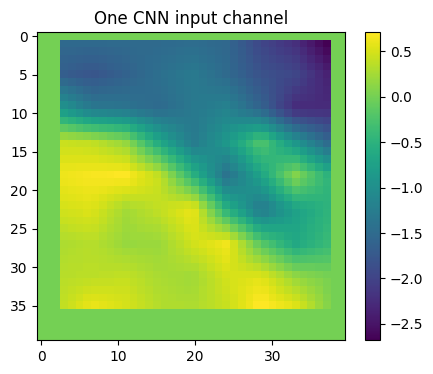

是否存在 NaN: False
是否存在 Inf: False


In [24]:
# ============================================================
# 23. 最后检查：确认 X 是否能用于 CNN
# ============================================================

sample = X_train[0]

print("单个样本 shape:", sample.shape)
print("通道数:", sample.shape[0])
print("网格大小:", sample.shape[1], sample.shape[2])

plt.figure(figsize=(5, 4))
plt.imshow(sample[0])
plt.title("One CNN input channel")
plt.colorbar()
plt.show()

print("是否存在 NaN:", np.isnan(X_train).any())
print("是否存在 Inf:", np.isinf(X_train).any())
